# Emotion Classification (Dataset 1) - Naive Bayes, Logistic Regression, and SVM with BoW and TF-IDF

## Imports

In [1]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
print("All libraries imported successfully!")

All libraries imported successfully!


## NLTK Resource Download

In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Load Dataset

In [3]:
df = pd.read_csv('Emotion_classify_Data.csv')
df.head()

,Comment,Emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear


## Dataset Overview

In [4]:
print(df.shape)
print(df['Emotion'].value_counts())

(5937, 2)
Emotion
anger    2000
joy      2000
fear     1937
Name: count, dtype: int64


## Handle Missing Values and Duplicates

In [5]:
df = df.dropna(subset=['Comment', 'Emotion'])
df = df.drop_duplicates(subset=['Comment'])
df = df.reset_index(drop=True)
df.shape

(5934, 2)

## Tokenization

In [6]:
df['tokens'] = df['Comment'].astype(str).apply(word_tokenize)
df[['Comment', 'tokens']].head()

,Comment,tokens
0,i seriously hate one subject to death but now ...,"[i, seriously, hate, one, subject, to, death, ..."
1,im so full of life i feel appalled,"[im, so, full, of, life, i, feel, appalled]"
2,i sit here to write i start to dig out my feel...,"[i, sit, here, to, write, i, start, to, dig, o..."
3,ive been really angry with r and i feel like a...,"[ive, been, really, angry, with, r, and, i, fe..."
4,i feel suspicious if there is no one outside l...,"[i, feel, suspicious, if, there, is, no, one, ..."


## Case Folding

In [7]:
def case_fold(tokens):
    return [t.lower() for t in tokens]

df['tokens'] = df['tokens'].apply(case_fold)
df['tokens'].head()

0    [i, seriously, hate, one, subject, to, death, ...
1          [im, so, full, of, life, i, feel, appalled]
2    [i, sit, here, to, write, i, start, to, dig, o...
3    [ive, been, really, angry, with, r, and, i, fe...
4    [i, feel, suspicious, if, there, is, no, one, ...
Name: tokens, dtype: object

## Punctuation Removal

In [8]:
punctuation_table = str.maketrans('', '', string.punctuation)
def remove_punctuation(tokens):
    cleaned = [t.translate(punctuation_table) for t in tokens]
    return [t for t in cleaned if t.strip() != '']
df['tokens'] = df['tokens'].apply(remove_punctuation)
df['tokens'].head()

0    [i, seriously, hate, one, subject, to, death, ...
1          [im, so, full, of, life, i, feel, appalled]
2    [i, sit, here, to, write, i, start, to, dig, o...
3    [ive, been, really, angry, with, r, and, i, fe...
4    [i, feel, suspicious, if, there, is, no, one, ...
Name: tokens, dtype: object

## Stop Words Removal

In [9]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]

df['tokens'] = df['tokens'].apply(remove_stopwords)
df['tokens'].head()

0    [seriously, hate, one, subject, death, feel, r...
1                     [im, full, life, feel, appalled]
2    [sit, write, start, dig, feelings, think, afra...
3    [ive, really, angry, r, feel, like, idiot, tru...
4    [feel, suspicious, one, outside, like, rapture...
Name: tokens, dtype: object

## Synonym Substitution

In [10]:
def get_synonym(word):
    synsets = wordnet.synsets(word)
    for synset in synsets:
        for lemma in synset.lemma_names():
            candidate = lemma.replace('_', ' ')
            if candidate.lower() != word.lower():
                return candidate.lower()
    return word

synonym_cache = {}
def substitute_synonyms(tokens):
    result = []
    for token in tokens:
        if token not in synonym_cache:
            synonym_cache[token] = get_synonym(token)
        result.append(synonym_cache[token])
    return result

df['tokens'] = df['tokens'].apply(substitute_synonyms)
df['tokens'].head()

0    [earnestly, hatred, 1, topic, decease, spirit,...
1               [im, full moon, living, spirit, shock]
2    [sit down, compose, beginning, excavation, fee...
3    [ive, truly, furious, roentgen, spirit, the li...
4    [spirit, leery, 1, exterior, the like, ecstasy...
Name: tokens, dtype: object

## Lemmatization

In [11]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

df['lemmatized_tokens'] = df['tokens'].apply(lemmatize_tokens)
df['lemmatized_tokens'].head()

0    [earnestly, hatred, 1, topic, decease, spirit,...
1               [im, full moon, living, spirit, shock]
2    [sit down, compose, beginning, excavation, fee...
3    [ive, truly, furious, roentgen, spirit, the li...
4    [spirit, leery, 1, exterior, the like, ecstasy...
Name: lemmatized_tokens, dtype: object

## Reconstruct Cleaned Text

In [12]:
def join_tokens(tokens):
    return ' '.join(tokens)

df['clean_text'] = df['lemmatized_tokens'].apply(join_tokens)
df = df[df['clean_text'].str.strip() != '']
df = df.reset_index(drop=True)
df[['clean_text']].head()

,clean_text
0,earnestly hatred 1 topic decease spirit loath ...
1,im full moon living spirit shock
2,sit down compose beginning excavation feeling ...
3,ive truly furious roentgen spirit the like imb...
4,spirit leery 1 exterior the like ecstasy happe...


## Label Encoding

In [13]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Emotion'])
print(df['label'])
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

0       1
1       0
2       1
3       2
4       1
       ..
5929    1
5930    0
5931    2
5932    1
5933    0
Name: label, Length: 5934, dtype: int64
{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2)}


## Train-Test Split

In [14]:
X_train_text, X_test_text, y_train, y_test = train_test_split(df['clean_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label'])
X_train_text.shape, X_test_text.shape

((4747,), (1187,))

## Bag-of-Words Vectorization

In [15]:
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train_text)
X_test_bow = bow_vectorizer.transform(X_test_text)
X_train_bow.shape

(4747, 6269)

## TF-IDF Vectorization

In [16]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)
X_train_tfidf.shape

(4747, 6269)

## Evaluation Helper

In [17]:
results = {}
def evaluate_model(name, representation, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    results[(name, representation)] = {
        'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1
    }
    print(name, '-', representation)
    print('Accuracy: ', accuracy)
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))

## Naive Bayes with Bag-of-Words

In [18]:
nb_bow_model = MultinomialNB()
nb_bow_model.fit(X_train_bow, y_train)
nb_bow_predictions = nb_bow_model.predict(X_test_bow)
evaluate_model('Naive Bayes', 'BoW', y_test, nb_bow_predictions)

Naive Bayes - BoW
Accuracy:  0.8719460825610783
              precision    recall  f1-score   support

       anger       0.87      0.88      0.87       400
        fear       0.83      0.89      0.86       387
         joy       0.92      0.85      0.88       400

    accuracy                           0.87      1187
   macro avg       0.87      0.87      0.87      1187
weighted avg       0.87      0.87      0.87      1187



## Naive Bayes with TF-IDF

In [19]:
nb_tfidf_model = MultinomialNB()
nb_tfidf_model.fit(X_train_tfidf, y_train)
nb_tfidf_predictions = nb_tfidf_model.predict(X_test_tfidf)
evaluate_model('Naive Bayes', 'TF-IDF', y_test, nb_tfidf_predictions)

Naive Bayes - TF-IDF
Accuracy:  0.8761583824768323
              precision    recall  f1-score   support

       anger       0.88      0.87      0.87       400
        fear       0.86      0.89      0.87       387
         joy       0.89      0.87      0.88       400

    accuracy                           0.88      1187
   macro avg       0.88      0.88      0.88      1187
weighted avg       0.88      0.88      0.88      1187



## Logistic Regression with Bag-of-Words

In [20]:
lr_bow_model = LogisticRegression(max_iter=1000)
lr_bow_model.fit(X_train_bow, y_train)
lr_bow_predictions = lr_bow_model.predict(X_test_bow)
evaluate_model('Logistic Regression', 'BoW', y_test, lr_bow_predictions)

Logistic Regression - BoW
Accuracy:  0.9250210614995787
              precision    recall  f1-score   support

       anger       0.92      0.90      0.91       400
        fear       0.91      0.94      0.92       387
         joy       0.94      0.94      0.94       400

    accuracy                           0.93      1187
   macro avg       0.92      0.93      0.92      1187
weighted avg       0.93      0.93      0.92      1187



## Logistic Regression with TF-IDF

In [21]:
lr_tfidf_model = LogisticRegression(max_iter=1000)
lr_tfidf_model.fit(X_train_tfidf, y_train)
lr_tfidf_predictions = lr_tfidf_model.predict(X_test_tfidf)
evaluate_model('Logistic Regression', 'TF-IDF', y_test, lr_tfidf_predictions)

Logistic Regression - TF-IDF
Accuracy:  0.9165964616680707
              precision    recall  f1-score   support

       anger       0.92      0.89      0.91       400
        fear       0.91      0.91      0.91       387
         joy       0.91      0.95      0.93       400

    accuracy                           0.92      1187
   macro avg       0.92      0.92      0.92      1187
weighted avg       0.92      0.92      0.92      1187



## Support Vector Machine with Bag-of-Words

In [22]:
svm_bow_model = LinearSVC()
svm_bow_model.fit(X_train_bow, y_train)
svm_bow_predictions = svm_bow_model.predict(X_test_bow)
evaluate_model('Support Vector Machine', 'BoW', y_test, svm_bow_predictions)

Support Vector Machine - BoW
Accuracy:  0.928390901432182
              precision    recall  f1-score   support

       anger       0.93      0.90      0.92       400
        fear       0.90      0.94      0.92       387
         joy       0.95      0.94      0.95       400

    accuracy                           0.93      1187
   macro avg       0.93      0.93      0.93      1187
weighted avg       0.93      0.93      0.93      1187



## Support Vector Machine with TF-IDF

In [23]:
svm_tfidf_model = LinearSVC()
svm_tfidf_model.fit(X_train_tfidf, y_train)
svm_tfidf_predictions = svm_tfidf_model.predict(X_test_tfidf)
evaluate_model('Support Vector Machine', 'TF-IDF', y_test, svm_tfidf_predictions)

Support Vector Machine - TF-IDF
Accuracy:  0.9267059814658803
              precision    recall  f1-score   support

       anger       0.92      0.91      0.92       400
        fear       0.92      0.93      0.93       387
         joy       0.94      0.94      0.94       400

    accuracy                           0.93      1187
   macro avg       0.93      0.93      0.93      1187
weighted avg       0.93      0.93      0.93      1187



## Results Summary Table

In [24]:
results_df = pd.DataFrame(results).T
results_df.index.names = ['Algorithm', 'Representation']
results_df

Accuracy  Precision    Recall  F1-Score
Algorithm              Representation                                         
Naive Bayes            BoW             0.871946   0.873914  0.871946  0.872187
                       TF-IDF          0.876158   0.876472  0.876158  0.876186
Logistic Regression    BoW             0.925021   0.925100  0.925021  0.924951
                       TF-IDF          0.916596   0.916702  0.916596  0.916430
Support Vector Machine BoW             0.928391   0.928792  0.928391  0.928407
                       TF-IDF          0.926706   0.926679  0.926706  0.926674

## Confusion Matrix of the Best Performing Model

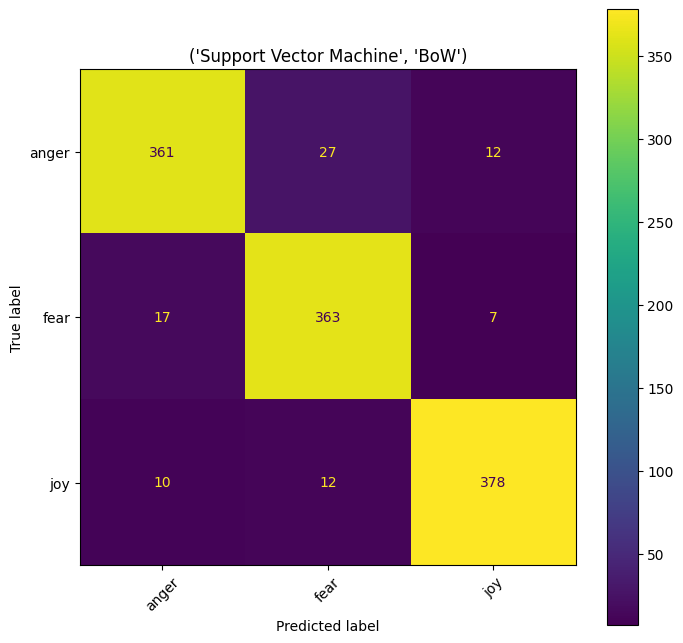

In [25]:
best_key = max(results, key=lambda k: results[k]['Accuracy'])
predictions_map = {
    ('Naive Bayes', 'BoW'): nb_bow_predictions,
    ('Naive Bayes', 'TF-IDF'): nb_tfidf_predictions,
    ('Logistic Regression', 'BoW'): lr_bow_predictions,
    ('Logistic Regression', 'TF-IDF'): lr_tfidf_predictions,
    ('Support Vector Machine', 'BoW'): svm_bow_predictions,
    ('Support Vector Machine', 'TF-IDF'): svm_tfidf_predictions,
}
best_predictions = predictions_map[best_key]
cm = confusion_matrix(y_test, best_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(8, 8))
cm_display.plot(ax=ax, xticks_rotation=45)
plt.title(str(best_key))
plt.show()

# Emotion Dataset Classification (Dataset 2) - Naive Bayes, Logistic Regression and SVM with BoW and TF-IDF

## Imports

In [26]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## NLTK Resource Download

In [27]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Load Dataset

In [28]:
import os

data_dir = 'Emotion Dataset'
split_files = ['train.txt', 'val.txt', 'test.txt']

frames = []
for split_file in split_files:
    file_path = os.path.join(data_dir, split_file)
    temp_df = pd.read_csv(file_path, sep=';', header=None, names=['content', 'sentiment'])
    frames.append(temp_df)

df = pd.concat(frames, ignore_index=True)
df.head()

,content,sentiment
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


## Dataset Overview

In [29]:
print(df.shape)
print(df['sentiment'].value_counts())

(20000, 2)
sentiment
joy         6761
sadness     5797
anger       2709
fear        2373
love        1641
surprise     719
Name: count, dtype: int64


## Handle Missing Values and Duplicates

In [30]:
df = df.dropna(subset=['content', 'sentiment'])
df = df.drop_duplicates(subset=['content'])
df = df.reset_index(drop=True)
df.shape

(19948, 2)

## Tokenization

In [31]:
df['tokens'] = df['content'].astype(str).apply(word_tokenize)
df[['content', 'tokens']].head()

,content,tokens
0,i didnt feel humiliated,"[i, didnt, feel, humiliated]"
1,i can go from feeling so hopeless to so damned...,"[i, can, go, from, feeling, so, hopeless, to, ..."
2,im grabbing a minute to post i feel greedy wrong,"[im, grabbing, a, minute, to, post, i, feel, g..."
3,i am ever feeling nostalgic about the fireplac...,"[i, am, ever, feeling, nostalgic, about, the, ..."
4,i am feeling grouchy,"[i, am, feeling, grouchy]"


## Case Folding

In [32]:
def case_fold(tokens):
    return [t.lower() for t in tokens]

df['tokens'] = df['tokens'].apply(case_fold)
df['tokens'].head()

0                         [i, didnt, feel, humiliated]
1    [i, can, go, from, feeling, so, hopeless, to, ...
2    [im, grabbing, a, minute, to, post, i, feel, g...
3    [i, am, ever, feeling, nostalgic, about, the, ...
4                            [i, am, feeling, grouchy]
Name: tokens, dtype: object

## Punctuation Removal

In [33]:
punctuation_table = str.maketrans('', '', string.punctuation)
def remove_punctuation(tokens):
    cleaned = [t.translate(punctuation_table) for t in tokens]
    return [t for t in cleaned if t.strip() != '']
df['tokens'] = df['tokens'].apply(remove_punctuation)
df['tokens'].head()

0                         [i, didnt, feel, humiliated]
1    [i, can, go, from, feeling, so, hopeless, to, ...
2    [im, grabbing, a, minute, to, post, i, feel, g...
3    [i, am, ever, feeling, nostalgic, about, the, ...
4                            [i, am, feeling, grouchy]
Name: tokens, dtype: object

## Stop Words Removal

In [34]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]

df['tokens'] = df['tokens'].apply(remove_stopwords)
df['tokens'].head()

0                            [didnt, feel, humiliated]
1    [go, feeling, hopeless, damned, hopeful, aroun...
2    [im, grabbing, minute, post, feel, greedy, wrong]
3    [ever, feeling, nostalgic, fireplace, know, st...
4                                   [feeling, grouchy]
Name: tokens, dtype: object

## Synonym Substitution

In [35]:
def get_synonym(word):
    synsets = wordnet.synsets(word)
    for synset in synsets:
        for lemma in synset.lemma_names():
            candidate = lemma.replace('_', ' ')
            if candidate.lower() != word.lower():
                return candidate.lower()
    return word

synonym_cache = {}
def substitute_synonyms(tokens):
    result = []
    for token in tokens:
        if token not in synonym_cache:
            synonym_cache[token] = get_synonym(token)
        result.append(synonym_cache[token])
    return result

df['tokens'] = df['tokens'].apply(substitute_synonyms)
df['tokens'].head()

0                           [didnt, spirit, humiliate]
1    [spell, impression, hopeless, curse, aspirant,...
2    [im, catch, min, station, spirit, avaricious, ...
3    [of all time, impression, nostalgic, hearth, c...
4                                [impression, crabbed]
Name: tokens, dtype: object

## Lemmatization

In [36]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

df['lemmatized_tokens'] = df['tokens'].apply(lemmatize_tokens)
df['lemmatized_tokens'].head()

0                           [didnt, spirit, humiliate]
1    [spell, impression, hopeless, curse, aspirant,...
2    [im, catch, min, station, spirit, avaricious, ...
3    [of all time, impression, nostalgic, hearth, c...
4                                [impression, crabbed]
Name: lemmatized_tokens, dtype: object

## Reconstruct Cleaned Text

In [37]:
def join_tokens(tokens):
    return ' '.join(tokens)

df['clean_text'] = df['lemmatized_tokens'].apply(join_tokens)
df = df[df['clean_text'].str.strip() != '']
df = df.reset_index(drop=True)
df[['clean_text']].head()

,clean_text
0,didnt spirit humiliate
1,spell impression hopeless curse aspirant about...
2,im catch min station spirit avaricious wrongfu...
3,of all time impression nostalgic hearth cogniz...
4,impression crabbed


## Label Encoding

In [38]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])
dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

{'anger': np.int64(0),
 'fear': np.int64(1),
 'joy': np.int64(2),
 'love': np.int64(3),
 'sadness': np.int64(4),
 'surprise': np.int64(5)}

## Train-Test Split

In [39]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)
X_train_text.shape, X_test_text.shape

((15958,), (3990,))

## Bag-of-Words Vectorization

In [40]:
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train_text)
X_test_bow = bow_vectorizer.transform(X_test_text)
X_train_bow.shape

(15958, 11295)

## TF-IDF Vectorization

In [41]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)
X_train_tfidf.shape

(15958, 11295)

## Evaluation Helper

In [42]:
results = {}
def evaluate_model(name, representation, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    results[(name, representation)] = {
        'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1
    }
    print(name, '-', representation)
    print('Accuracy: ', accuracy)
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))

## Naive Bayes with Bag-of-Words

In [43]:
nb_bow_model = MultinomialNB()
nb_bow_model.fit(X_train_bow, y_train)
nb_bow_predictions = nb_bow_model.predict(X_test_bow)
evaluate_model('Naive Bayes', 'BoW', y_test, nb_bow_predictions)

Naive Bayes - BoW
Accuracy:  0.7636591478696741
              precision    recall  f1-score   support

       anger       0.82      0.64      0.72       540
        fear       0.83      0.58      0.68       474
         joy       0.76      0.93      0.83      1348
        love       0.79      0.33      0.47       326
     sadness       0.73      0.91      0.81      1159
    surprise       1.00      0.10      0.18       143

    accuracy                           0.76      3990
   macro avg       0.82      0.58      0.62      3990
weighted avg       0.78      0.76      0.74      3990



## Naive Bayes with TF-IDF

In [44]:
nb_tfidf_model = MultinomialNB()
nb_tfidf_model.fit(X_train_tfidf, y_train)
nb_tfidf_predictions = nb_tfidf_model.predict(X_test_tfidf)
evaluate_model('Naive Bayes', 'TF-IDF', y_test, nb_tfidf_predictions)

Naive Bayes - TF-IDF
Accuracy:  0.6631578947368421
              precision    recall  f1-score   support

       anger       0.92      0.31      0.47       540
        fear       0.97      0.24      0.39       474
         joy       0.62      0.97      0.75      1348
        love       0.88      0.05      0.09       326
     sadness       0.67      0.89      0.77      1159
    surprise       1.00      0.02      0.04       143

    accuracy                           0.66      3990
   macro avg       0.84      0.41      0.42      3990
weighted avg       0.75      0.66      0.60      3990



## Logistic Regression with Bag-of-Words

In [45]:
lr_bow_model = LogisticRegression(max_iter=1000)
lr_bow_model.fit(X_train_bow, y_train)
lr_bow_predictions = lr_bow_model.predict(X_test_bow)
evaluate_model('Logistic Regression', 'BoW', y_test, lr_bow_predictions)

Logistic Regression - BoW
Accuracy:  0.8644110275689223
              precision    recall  f1-score   support

       anger       0.85      0.83      0.84       540
        fear       0.84      0.81      0.82       474
         joy       0.90      0.91      0.90      1348
        love       0.75      0.71      0.73       326
     sadness       0.89      0.92      0.90      1159
    surprise       0.73      0.66      0.70       143

    accuracy                           0.86      3990
   macro avg       0.83      0.81      0.82      3990
weighted avg       0.86      0.86      0.86      3990



## Logistic Regression with TF-IDF

In [46]:
lr_tfidf_model = LogisticRegression(max_iter=1000)
lr_tfidf_model.fit(X_train_tfidf, y_train)
lr_tfidf_predictions = lr_tfidf_model.predict(X_test_tfidf)
evaluate_model('Logistic Regression', 'TF-IDF', y_test, lr_tfidf_predictions)

Logistic Regression - TF-IDF
Accuracy:  0.8401002506265665
              precision    recall  f1-score   support

       anger       0.84      0.77      0.81       540
        fear       0.85      0.71      0.78       474
         joy       0.83      0.94      0.88      1348
        love       0.82      0.60      0.69       326
     sadness       0.86      0.92      0.89      1159
    surprise       0.84      0.47      0.60       143

    accuracy                           0.84      3990
   macro avg       0.84      0.74      0.77      3990
weighted avg       0.84      0.84      0.83      3990



## Support Vector Machine with Bag-of-Words

In [47]:
svm_bow_model = LinearSVC()
svm_bow_model.fit(X_train_bow, y_train)
svm_bow_predictions = svm_bow_model.predict(X_test_bow)
evaluate_model('Support Vector Machine', 'BoW', y_test, svm_bow_predictions)

Support Vector Machine - BoW
Accuracy:  0.8583959899749374
              precision    recall  f1-score   support

       anger       0.84      0.83      0.83       540
        fear       0.82      0.81      0.82       474
         joy       0.90      0.89      0.89      1348
        love       0.75      0.75      0.75       326
     sadness       0.89      0.91      0.90      1159
    surprise       0.70      0.66      0.68       143

    accuracy                           0.86      3990
   macro avg       0.81      0.81      0.81      3990
weighted avg       0.86      0.86      0.86      3990



## Support Vector Machine with TF-IDF

In [48]:
svm_tfidf_model = LinearSVC()
svm_tfidf_model.fit(X_train_tfidf, y_train)
svm_tfidf_predictions = svm_tfidf_model.predict(X_test_tfidf)
evaluate_model('Support Vector Machine', 'TF-IDF', y_test, svm_tfidf_predictions)

Support Vector Machine - TF-IDF
Accuracy:  0.8694235588972431
              precision    recall  f1-score   support

       anger       0.86      0.84      0.85       540
        fear       0.86      0.82      0.84       474
         joy       0.90      0.91      0.91      1348
        love       0.74      0.72      0.73       326
     sadness       0.89      0.92      0.90      1159
    surprise       0.80      0.64      0.71       143

    accuracy                           0.87      3990
   macro avg       0.84      0.81      0.82      3990
weighted avg       0.87      0.87      0.87      3990



## Results Summary Table

In [49]:
results_df = pd.DataFrame(results).T
results_df.index.names = ['Algorithm', 'Representation']
results_df

Accuracy  Precision    Recall  F1-Score
Algorithm              Representation                                         
Naive Bayes            BoW             0.763659   0.779152  0.763659  0.740732
                       TF-IDF          0.663158   0.750875  0.663158  0.595499
Logistic Regression    BoW             0.864411   0.862903  0.864411  0.863408
                       TF-IDF          0.840100   0.840168  0.840100  0.834341
Support Vector Machine BoW             0.858396   0.857904  0.858396  0.858075
                       TF-IDF          0.869424   0.868162  0.869424  0.868287

## Confusion Matrix of the Best Performing Model

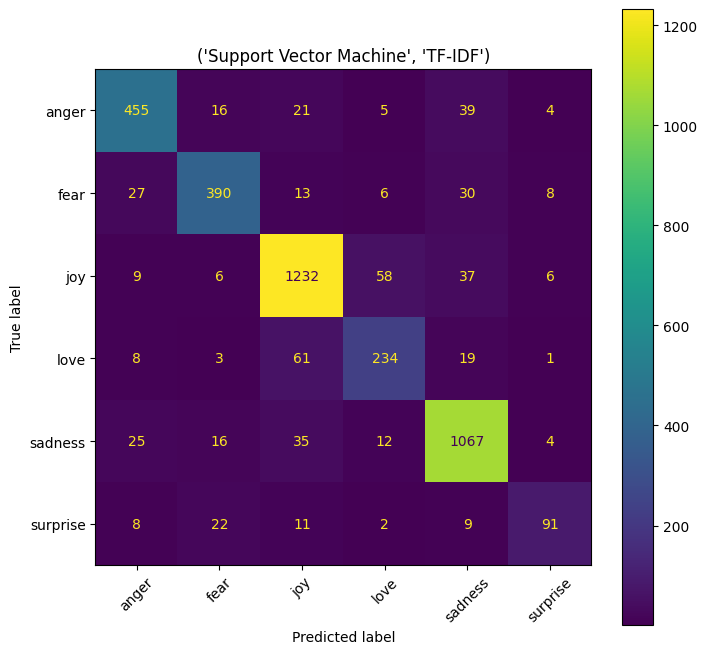

In [50]:
best_key = max(results, key=lambda k: results[k]['Accuracy'])
predictions_map = {
    ('Naive Bayes', 'BoW'): nb_bow_predictions,
    ('Naive Bayes', 'TF-IDF'): nb_tfidf_predictions,
    ('Logistic Regression', 'BoW'): lr_bow_predictions,
    ('Logistic Regression', 'TF-IDF'): lr_tfidf_predictions,
    ('Support Vector Machine', 'BoW'): svm_bow_predictions,
    ('Support Vector Machine', 'TF-IDF'): svm_tfidf_predictions,
}
best_predictions = predictions_map[best_key]
cm = confusion_matrix(y_test, best_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(8, 8))
cm_display.plot(ax=ax, xticks_rotation=45)
plt.title(str(best_key))
plt.show()